<a href="https://colab.research.google.com/github/KarthikSaravanakumarM56/24ADI003-24BAD056/blob/main/ML_Exp_10_scenario2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

24BAD056 - M.Karthik Saravanakumar
NMF RMSE: 0.8681784424832709
Precision@5 (User 1): 1.0
Recall@5 (User 1): 0.025

Top Recommendations for User 1:
      movieId                              title
474       541                Blade Runner (1982)
507       589  Terminator 2: Judgment Day (1991)
659       858              Godfather, The (1972)
902      1200                      Aliens (1986)
1067     1387                        Jaws (1975)


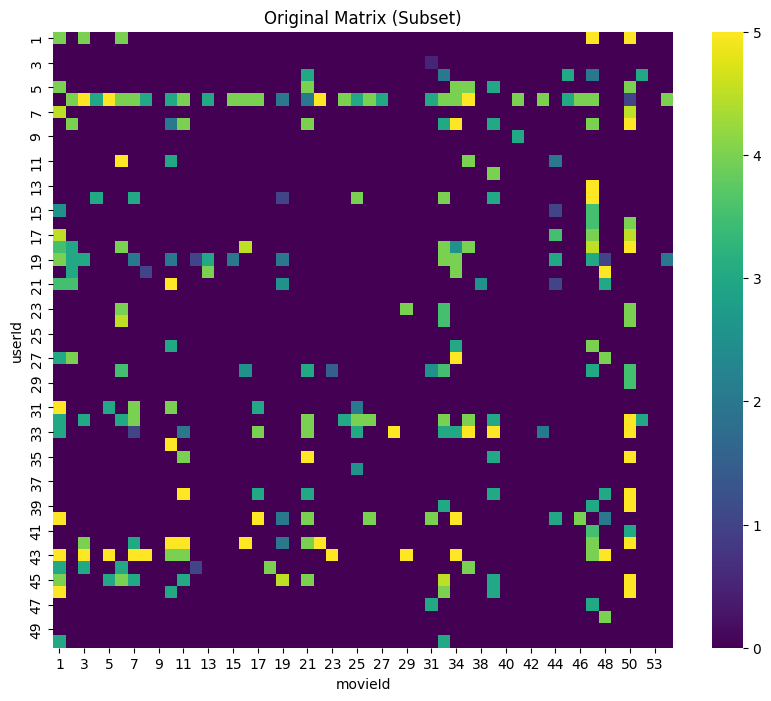

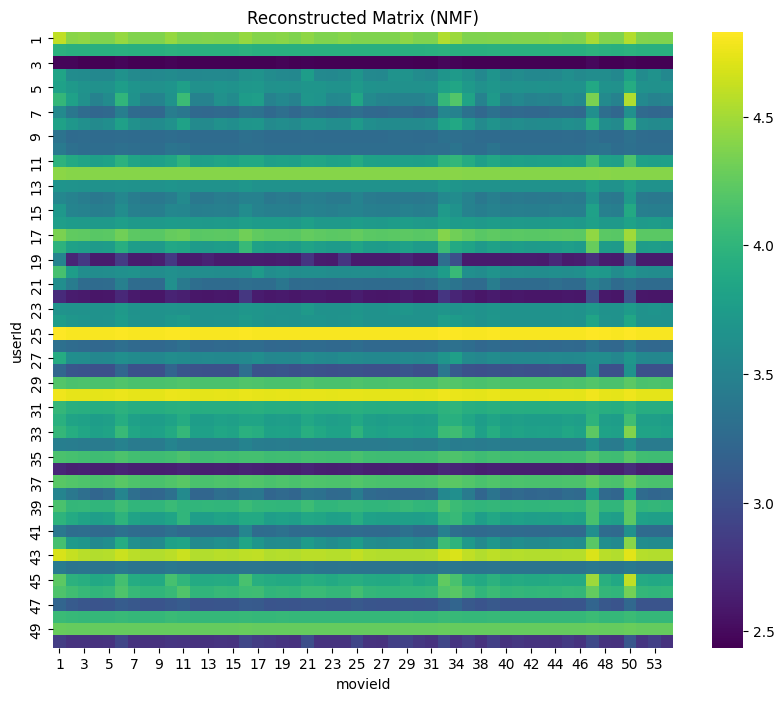

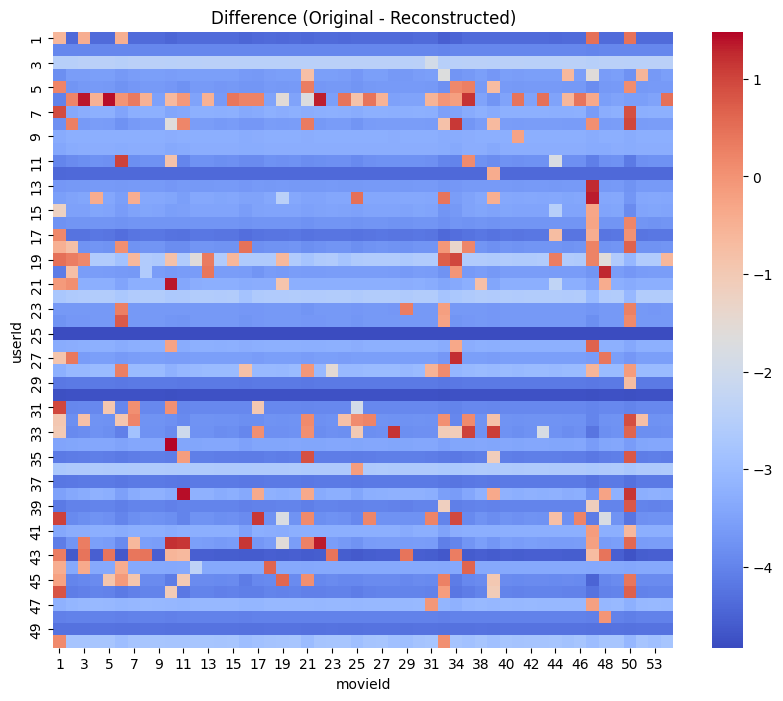

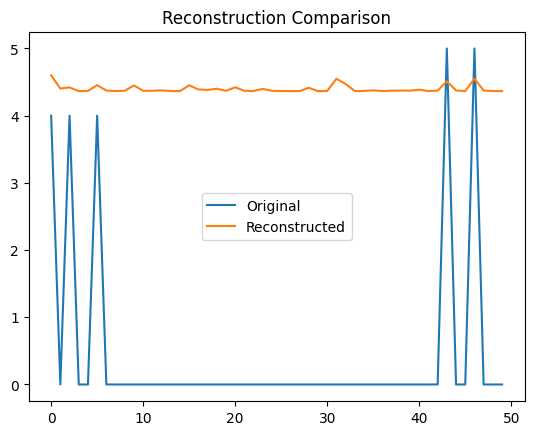

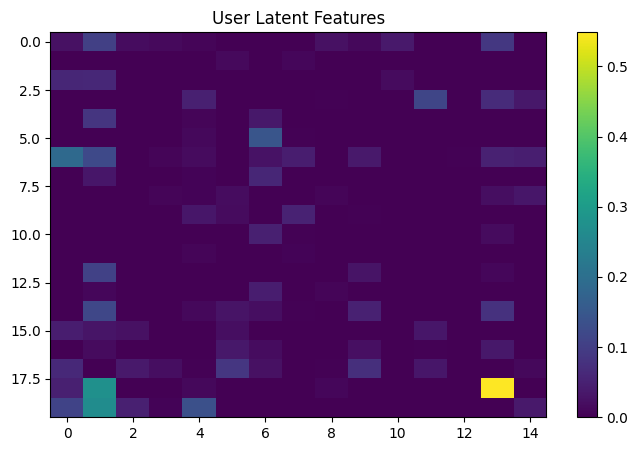

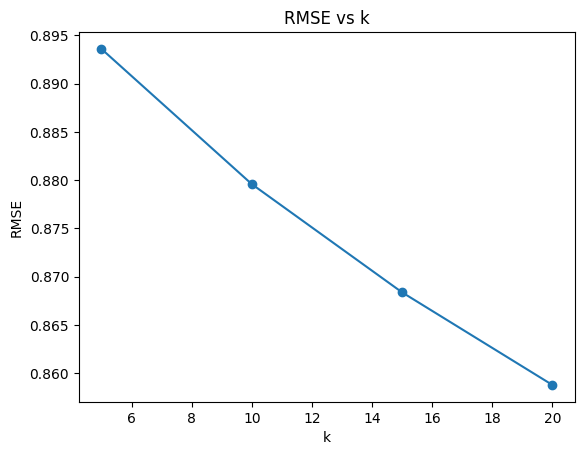

In [2]:
print("24BAD056 - M.Karthik Saravanakumar")

# 1. IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error

# 2. LOAD DATASET
ratings = pd.read_csv('ratings.csv', engine='python', on_bad_lines='skip')
movies = pd.read_csv('movies.csv', engine='python', on_bad_lines='skip')

if 'timestamp' in ratings.columns:
    ratings = ratings.drop('timestamp', axis=1)

ratings = ratings.dropna()

# 3. USER-ITEM MATRIX
user_item_matrix = ratings.pivot(index='userId', columns='movieId', values='rating')

# 4. NORMALIZATION (IMPORTANT FIX)
# Mean centering (similar to SVD improvement)
user_mean = user_item_matrix.mean(axis=1)
matrix_norm = user_item_matrix.sub(user_mean, axis=0)

# Fill missing values AFTER normalization
matrix_filled = matrix_norm.fillna(0)

# 5. APPLY NMF
k = 15
model = NMF(n_components=k, init='random', random_state=42, max_iter=300)

W = model.fit_transform(np.maximum(matrix_filled, 0))  # ensure non-negative
H = model.components_

# 6. RECONSTRUCTION
reconstructed = np.dot(W, H)

# Add mean back
reconstructed += user_mean.values.reshape(-1, 1)

pred_nmf = pd.DataFrame(reconstructed,
                        index=user_item_matrix.index,
                        columns=user_item_matrix.columns)

# 7. EVALUATION
mask = user_item_matrix.notna()

actual = user_item_matrix.values[mask]
predicted = pred_nmf.values[mask]

rmse = np.sqrt(mean_squared_error(actual, predicted))
print("NMF RMSE:", rmse)

# 8. PRECISION & RECALL
def precision_at_k(user_id, k=5):
    recommended = pred_nmf.loc[user_id].sort_values(ascending=False).head(k).index
    relevant = user_item_matrix.loc[user_id][user_item_matrix.loc[user_id] >= 4].index
    return len(set(recommended) & set(relevant)) / k

def recall_at_k(user_id, k=5):
    recommended = pred_nmf.loc[user_id].sort_values(ascending=False).head(k).index
    relevant = user_item_matrix.loc[user_id][user_item_matrix.loc[user_id] >= 4].index
    return len(set(recommended) & set(relevant)) / len(relevant) if len(relevant) > 0 else 0

print("Precision@5 (User 1):", precision_at_k(1))
print("Recall@5 (User 1):", recall_at_k(1))

# 9. RECOMMENDATIONS
def recommend_nmf(user_id, n=5):
    user_row = pred_nmf.loc[user_id]
    already_rated = user_item_matrix.loc[user_id].dropna().index
    recs = user_row.drop(already_rated).sort_values(ascending=False).head(n)
    return movies[movies['movieId'].isin(recs.index)][['movieId', 'title']]

print("\nTop Recommendations for User 1:")
print(recommend_nmf(1))

# 10. VISUALIZATION
subset_original = user_item_matrix.fillna(0).iloc[:50, :50]
subset_reconstructed = pred_nmf.iloc[:50, :50]

plt.figure(figsize=(10, 8))
sns.heatmap(subset_original, cmap='viridis')
plt.title("Original Matrix (Subset)")
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(subset_reconstructed, cmap='viridis')
plt.title("Reconstructed Matrix (NMF)")
plt.show()

difference = subset_original - subset_reconstructed

plt.figure(figsize=(10, 8))
sns.heatmap(difference, cmap='coolwarm')
plt.title("Difference (Original - Reconstructed)")
plt.show()

# 11. RECONSTRUCTION COMPARISON
plt.figure()
plt.plot(user_item_matrix.iloc[0].fillna(0).values[:50], label='Original')
plt.plot(pred_nmf.iloc[0].values[:50], label='Reconstructed')
plt.legend()
plt.title("Reconstruction Comparison")
plt.show()

# 12. LATENT FEATURE VISUALIZATION
plt.figure(figsize=(8, 5))
plt.imshow(W[:20, :], aspect='auto')
plt.colorbar()
plt.title("User Latent Features")
plt.show()

# 13. ERROR vs k
k_values = [5, 10, 15, 20]
rmse_values = []

for k in k_values:
    model = NMF(n_components=k, random_state=42, max_iter=300)
    W_temp = model.fit_transform(np.maximum(matrix_filled, 0))
    H_temp = model.components_
    pred_temp = np.dot(W_temp, H_temp)
    pred_temp += user_mean.values.reshape(-1, 1)

    pred_df = pd.DataFrame(pred_temp,
                           index=user_item_matrix.index,
                           columns=user_item_matrix.columns)

    pred_vals = pred_df.values[mask]
    rmse_k = np.sqrt(mean_squared_error(actual, pred_vals))
    rmse_values.append(rmse_k)

plt.figure()
plt.plot(k_values, rmse_values, marker='o')
plt.title("RMSE vs k")
plt.xlabel("k")
plt.ylabel("RMSE")
plt.show()